In [15]:
import numpy as np
import math
import time
from connect4.connect_state import ConnectState
from connect4.policy import Policy
from connect4.utils import find_importable_classes
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
# ============================================
# 3. Round-robin entre TODAS las políticas
# ============================================

participants = find_importable_classes("groups", Policy)
names = list(participants.keys())

rows = []

for i in range(len(names)):
    for j in range(i+1, len(names)):
        A_Class = participants[names[i]] # Renombrado para claridad
        B_Class = participants[names[j]] # Renombrado para claridad
        
        # Obtener el nombre de la clase 
        name_A = A_Class.__name__
        name_B = B_Class.__name__

        print(f"Evaluando {name_A} vs {name_B}...") # Usar nombres de clase
        
        res = evaluate_pair(A_Class, B_Class, games=20)

        total = 20

        rows.append({
            "A": name_A, # <-- Nombre de la clase
            "B": name_B, # <-- Nombre de la clase
            **res,
            "A_total_wins": res["A_red_wins"] + res["A_yellow_wins"],
            "B_total_wins": res["B_red_wins"] + res["B_yellow_wins"],
            "A_winrate": (res["A_red_wins"] + res["A_yellow_wins"]) / total,
            "B_winrate": (res["B_red_wins"] + res["B_yellow_wins"]) / total,
            "draw_rate": res["draws"] / total,
        })

results_df = pd.DataFrame(rows)
results_df

Evaluando Heuristic vs Random...
Evaluando Heuristic vs MAN...
Evaluando Heuristic vs NICOLAS...
Evaluando Random vs MAN...
Evaluando Random vs NICOLAS...
Evaluando MAN vs NICOLAS...


,A,B,A_red_wins,A_yellow_wins,B_red_wins,B_yellow_wins,draws,A_total_wins,B_total_wins,A_winrate,B_winrate,draw_rate
0,Heuristic,Random,10,10,0,0,0,20,0,1.0,0.0,0.0
1,Heuristic,MAN,3,1,8,6,2,4,14,0.2,0.7,0.1
2,Heuristic,NICOLAS,10,10,0,0,0,20,0,1.0,0.0,0.0
3,Random,MAN,0,0,10,10,0,0,20,0.0,1.0,0.0
4,Random,NICOLAS,2,2,8,8,0,4,16,0.2,0.8,0.0
5,MAN,NICOLAS,10,10,0,0,0,20,0,1.0,0.0,0.0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# games=2, half_games=1
half_games = 20 // 2 
names = results_df["A"].unique() # Lista de nombres de las clases 

# Crea una matriz inicial cuadrada de NaN con los nombres de las políticas
def initialize_pivot_table(names):
    pivot = pd.DataFrame(index=names, columns=names)
    np.fill_diagonal(pivot.values, np.nan) # NaN en la diagonal (A vs A)
    return pivot

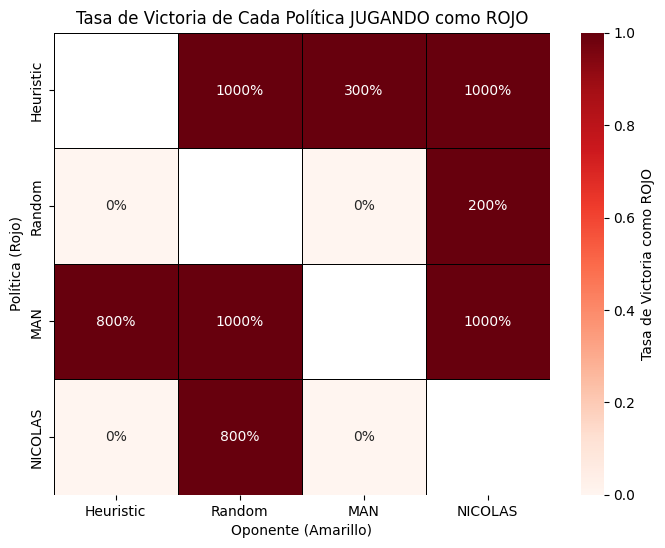

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# games=2, half_games=1
half_games = 20 // 2 
names = results_df["A"].unique() # Lista de nombres de las clases (e.g., 'MAN', 'GroupD', etc.)

# Crea una matriz inicial cuadrada de NaN con los nombres de las políticas
def initialize_pivot_table(names):
    pivot = pd.DataFrame(index=names, columns=names)
    np.fill_diagonal(pivot.values, np.nan) # NaN en la diagonal (A vs A)
    return pivot

## 1. Mapa de Calor: Victorias como ROJO (%)
pivot_rojo = initialize_pivot_table(names)

for index, row in results_df.iterrows():
    name_A = row["A"]
    name_B = row["B"]
    
    # Tasa de victoria de A como ROJO contra B
    winrate_A_rojo = row["A_red_wins"] / half_games
    pivot_rojo.loc[name_A, name_B] = winrate_A_rojo
    
    # Tasa de victoria de B como ROJO contra A
    winrate_B_rojo = row["B_red_wins"] / half_games
    pivot_rojo.loc[name_B, name_A] = winrate_B_rojo

plt.figure(figsize=(8, 6))
# APLICA LA CONVERSIÓN A FLOAT AQUÍ: .astype(float)
sns.heatmap(pivot_rojo.astype(float), annot=True, cmap="Reds", fmt=".0%",
            linewidths=.5, linecolor='black', vmin=0, vmax=1,
            cbar_kws={'label': 'Tasa de Victoria como ROJO'})
plt.title("Tasa de Victoria de Cada Política JUGANDO como ROJO")
plt.xlabel("Oponente (Amarillo)")
plt.ylabel("Política (Rojo)")
plt.savefig("mapa_calor_rojo.png")

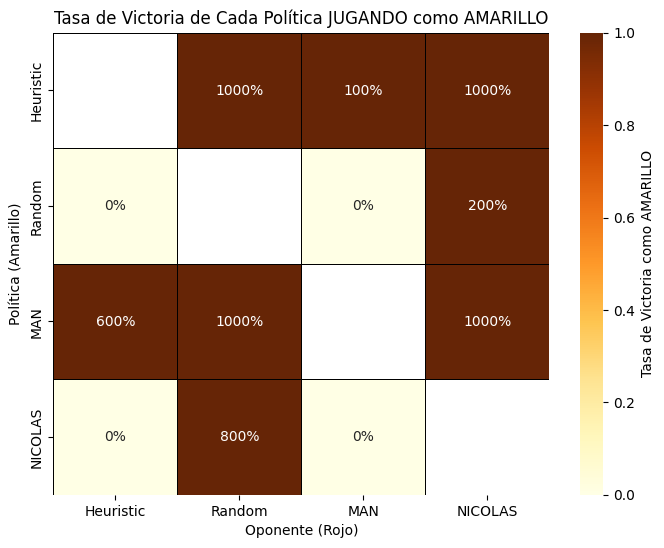

In [19]:
## 2. Mapa de Calor: Victorias como AMARILLO (%)
pivot_amarillo = initialize_pivot_table(names)

for index, row in results_df.iterrows():
    name_A = row["A"]
    name_B = row["B"]
    
    # Tasa de victoria de A como AMARILLO contra B
    winrate_A_amarillo = row["A_yellow_wins"] / half_games
    pivot_amarillo.loc[name_A, name_B] = winrate_A_amarillo
    
    # Tasa de victoria de B como AMARILLO contra A
    winrate_B_amarillo = row["B_yellow_wins"] / half_games
    pivot_amarillo.loc[name_B, name_A] = winrate_B_amarillo

plt.figure(figsize=(8, 6))
# APLICA LA CONVERSIÓN A FLOAT AQUÍ: .astype(float)
sns.heatmap(pivot_amarillo.astype(float), annot=True, cmap="YlOrBr", fmt=".0%",
            linewidths=.5, linecolor='black', vmin=0, vmax=1,
            cbar_kws={'label': 'Tasa de Victoria como AMARILLO'})
plt.title("Tasa de Victoria de Cada Política JUGANDO como AMARILLO")
plt.xlabel("Oponente (Rojo)")
plt.ylabel("Política (Amarillo)")
plt.savefig("mapa_calor_amarillo.png")